# IY029: Synthetic-Data Pairwise SVM — All SimCLR Models (IY017–IY024)

Mirrors IY025 (`IY025_svm_pairwise_variation`) on a pairwise same/different task, but replaces raw trajectory features with SimCLR embeddings from all 34 trained models.

## Label structure (no artificial binning)
Labels are structurally given by the IY011/IY014 contrastive loaders:
- **Label 1 (same):** the two trajectories in the pair were drawn from the *same* parameter set
- **Label 0 (different):** the two trajectories were drawn from *different* parameter sets

Each loader sample is two concatenated trajectories; we split at the midpoint, crop to `SAMPLE_LEN=500`, encode each half with `model.backbone.encode`, and feed `|z1 − z2|` to an RBF SVM. Chance = 50%.

## Variation magnitudes (matching IY025)
- **IY011 (2-fold):** varied statistic differs ~2× between the two drawn parameter sets
- **IY014 (10-fold):** varied statistic differs ~10× between the two drawn parameter sets

## Datasets (4 conditions)
- **baseline** — μ, CV, t_ac all vary (Sobol sampling)
- **mu** — only μ varies
- **cv** — only CV varies
- **t_ac** — only t_ac varies

In [1]:
import sys
sys.path.insert(0, '../../src')

import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm

from dataloaders import load_loader_from_disk
from models.ssl_transformer import SSL_Transformer

# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':     'sans-serif',
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.titlesize':  14,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
EXP_DIR    = Path('../..')
IY011_ROOT = EXP_DIR / 'experiments/EXP-25-IY011'
IY014_ROOT = EXP_DIR / 'experiments/EXP-26-IY014'

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAMPLE_LEN = 500   # crop length fed to encoder (consistent with SimCLR training)

print(f'Device: {DEVICE}')

# ── Dataset config (mirrors IY025 exactly) ────────────────────────────────────
DATASET_CONFIGS = [
    {
        'name':        'Baseline',
        'iy011_train': IY011_ROOT / 'data'               / 'IY011_static_train.pt',
        'iy011_test':  IY011_ROOT / 'data'               / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data'               / 'IY014_static_train.pt',
        'iy014_test':  IY014_ROOT / 'data'               / 'IY014_static_test.pt',
    },
    {
        'name':        'Mu',
        'iy011_train': IY011_ROOT / 'data_mu_variation'  / 'IY011_static_train.pt',
        'iy011_test':  IY011_ROOT / 'data_mu_variation'  / 'IY011_static_test.pt',
        'iy014_train': IY011_ROOT / 'data_mu_variation'  / 'IY014_static_train.pt',
        'iy014_test':  IY011_ROOT / 'data_mu_variation'  / 'IY014_static_test.pt',
    },
    {
        'name':        'CV',
        'iy011_train': IY011_ROOT / 'data_cv_variation'  / 'IY011_static_train.pt',
        'iy011_test':  IY011_ROOT / 'data_cv_variation'  / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data_cv_variation'  / 'IY014_static_train.pt',
        'iy014_test':  IY014_ROOT / 'data_cv_variation'  / 'IY014_static_test.pt',
    },
    {
        'name':        'T_ac',
        'iy011_train': IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_train.pt',
        'iy011_test':  IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_train.pt',
        'iy014_test':  IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_test.pt',
    },
]


Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Registry (34 SimCLR checkpoints)

In [2]:
# Models without an explicit norm tag in their filename
NORM_OVERRIDES = {
    'IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model': 'global',
    'IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model': 'global',
    'IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model': 'joint',
    'IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model': 'global',
    'IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model': 'joint',
}


def parse_arch_from_name(name: str) -> dict:
    """Extract transformer architecture from checkpoint filename."""
    d_model    = int(re.search(r'_D(\d+)', name).group(1))
    nhead      = int(re.search(r'_H(\d+)', name).group(1))
    num_layers = int(re.search(r'_L(\d+)', name).group(1))
    return dict(input_size=1, d_model=d_model, nhead=nhead,
                num_layers=num_layers, dropout=0.01, use_conv1d=False)


def make_short_label(path: Path) -> str:
    """Human-readable model label from checkpoint path."""
    name = path.stem
    exp  = re.search(r'(IY\d+)', name).group(1)
    # Optional _d<float> between lr and _L handles checkpoints with explicit dropout
    arch_m = re.search(r'(b\d+_lr[\d.]+(?:_d[\d.]+)?_L\d+_H\d+_D\d+)', name)
    arch   = arch_m.group(1) if arch_m else re.search(r'(L\d+_H\d+_D\d+)', name).group(1)
    ts     = re.search(r'(\d{8}_\d{6})', name)
    ts     = ts.group(1)[-6:] if ts else ''
    norm   = (NORM_OVERRIDES.get(name)
              or (re.search(r'_(instance|global|joint)_', name) or [None, ''])[1]
              or 'instance')
    return f'{exp}-{arch}-{norm}-{ts}'


CKPT_DIRS = ['EXP-26-IY017', 'EXP-26-IY022', 'EXP-26-IY023', 'EXP-26-IY024']
MODEL_REGISTRY = [
    (p, make_short_label(p))
    for d in CKPT_DIRS
    for p in sorted((EXP_DIR / 'experiments' / d).glob('*.pth'))
]
print(f'Found {len(MODEL_REGISTRY)} model checkpoints')
for p, label in MODEL_REGISTRY:
    print(f'  {label}')


Found 34 model checkpoints
  IY017-b100_lr0.01_L2_H4_D128-instance-
  IY017-b100_lr0.01_d0.01_L2_H4_D128-instance-
  IY017-b1024_lr0.01_L2_H4_D16-instance-164413
  IY017-b1024_lr0.01_L2_H4_D16-instance-061239
  IY017-b128_lr0.01_L2_H4_D16-instance-151037
  IY017-b16_lr0.01_L2_H4_D16-instance-
  IY017-b16_lr0.01_d0.01_L2_H4_D16-instance-
  IY017-b2048_lr0.01_L2_H4_D16-instance-162432
  IY017-b256_lr0.01_L2_H4_D16-instance-154425
  IY017-b32_lr0.01_L2_H4_D128-instance-
  IY017-b4096_lr0.01_L2_H4_D16-instance-140729
  IY017-b4096_lr0.01_L2_H4_D16-instance-023947
  IY017-b512_lr0.01_L2_H4_D16-instance-154043
  IY017-b64_lr0.01_L2_H4_D16-instance-163742
  IY017-b64_lr0.01_L2_H4_D16-instance-100838
  IY017-b64_lr0.01_L2_H4_D16-instance-215100
  IY017-b64_lr0.01_L2_H4_D8-instance-092414
  IY017-b64_lr0.01_d0.01_L2_H4_D16-instance-
  IY022-b64_lr0.01_L2_H4_D16-global-170229
  IY022-b64_lr0.01_L2_H4_D16-global-125632
  IY022-b64_lr0.01_L2_H4_D16-joint-132219
  IY022-b64_lr0.01_L2_H4_D16-instanc

## Load Pairwise Data

In [3]:
def load_pair_data(train_pt: Path, test_pt: Path):
    """
    Load IY011/IY014 static pairwise loader.
    Each sample is shape (T, 1): two concatenated trajectories.
    Returns: X_train (N,T,1), X_test (M,T,1), y_train (N,), y_test (M,)
    """
    def _extract(pt_path):
        loader = load_loader_from_disk(pt_path, batch_size=2048)
        Xs, ys = [], []
        for X, y in loader:
            Xs.append(X.numpy())
            ys.append(y.numpy().ravel())
        return np.concatenate(Xs, axis=0), np.concatenate(ys).astype(int)

    X_train, y_train = _extract(train_pt)
    X_test,  y_test  = _extract(test_pt)
    return X_train, X_test, y_train, y_test


# Load all 4 datasets × 2 fold magnitudes
prepared_data = {}   # {ds_name: {'iy011': (Xtr,Xte,ytr,yte), 'iy014': ...}}
for cfg in DATASET_CONFIGS:
    name = cfg['name']
    print(f'Loading {name}...')
    prepared_data[name] = {
        'iy011': load_pair_data(cfg['iy011_train'], cfg['iy011_test']),
        'iy014': load_pair_data(cfg['iy014_train'], cfg['iy014_test']),
    }
    for fold, (Xtr, Xte, ytr, yte) in prepared_data[name].items():
        print(f'  {fold}: train={Xtr.shape}, test={Xte.shape}, '
              f'same={yte.sum()}, diff={(yte==0).sum()}')

Loading Baseline...
📂 Loading static data from ../../experiments/EXP-25-IY011/data/IY011_static_train.pt...
📂 Loading static data from ../../experiments/EXP-25-IY011/data/IY011_static_test.pt...
📂 Loading static data from ../../experiments/EXP-26-IY014/data/IY014_static_train.pt...
📂 Loading static data from ../../experiments/EXP-26-IY014/data/IY014_static_test.pt...
  iy011: train=(3000, 3623, 1), test=(600, 3623, 1), same=314, diff=286
  iy014: train=(3000, 3623, 1), test=(600, 3623, 1), same=314, diff=286
Loading Mu...
📂 Loading static data from ../../experiments/EXP-25-IY011/data_mu_variation/IY011_static_train.pt...


📂 Loading static data from ../../experiments/EXP-25-IY011/data_mu_variation/IY011_static_test.pt...
📂 Loading static data from ../../experiments/EXP-25-IY011/data_mu_variation/IY014_static_train.pt...
📂 Loading static data from ../../experiments/EXP-25-IY011/data_mu_variation/IY014_static_test.pt...
  iy011: train=(3000, 5021, 1), test=(600, 5021, 1), same=297, diff=303
  iy014: train=(3000, 5021, 1), test=(600, 5021, 1), same=326, diff=274
Loading CV...
📂 Loading static data from ../../experiments/EXP-25-IY011/data_cv_variation/IY011_static_train.pt...


📂 Loading static data from ../../experiments/EXP-25-IY011/data_cv_variation/IY011_static_test.pt...
📂 Loading static data from ../../experiments/EXP-26-IY014/data_cv_variation/IY014_static_train.pt...
📂 Loading static data from ../../experiments/EXP-26-IY014/data_cv_variation/IY014_static_test.pt...
  iy011: train=(3000, 5003, 1), test=(600, 5003, 1), same=296, diff=304
  iy014: train=(3000, 5821, 1), test=(600, 5821, 1), same=289, diff=311
Loading T_ac...
📂 Loading static data from ../../experiments/EXP-25-IY011/data_t_ac_variation/IY011_static_train.pt...
📂 Loading static data from ../../experiments/EXP-25-IY011/data_t_ac_variation/IY011_static_test.pt...
📂 Loading static data from ../../experiments/EXP-26-IY014/data_t_ac_variation/IY014_static_train.pt...


📂 Loading static data from ../../experiments/EXP-26-IY014/data_t_ac_variation/IY014_static_test.pt...
  iy011: train=(3000, 4023, 1), test=(600, 4023, 1), same=292, diff=308
  iy014: train=(3000, 3623, 1), test=(600, 3623, 1), same=320, diff=280


## Evaluation Helpers

In [4]:
def load_model(ckpt_path: Path, device) -> SSL_Transformer:
    """Instantiate SSL_Transformer from filename and load checkpoint weights."""
    arch  = parse_arch_from_name(ckpt_path.stem)
    model = SSL_Transformer(**arch).to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    return model


def encode_pairs(model: SSL_Transformer, X_np: np.ndarray,
                 device, batch_size: int = 256) -> np.ndarray:
    """
    X_np: (N, T, 1) concatenated pair array.
    Splits each sample at T//2, crops to SAMPLE_LEN, encodes each half, then
    concatenates [z1, z2] — analogous to IY025 which feeds the flattened pair
    directly to the SVM rather than computing a difference vector.
    Returns shape (N, 2 * d_model).
    """
    T    = X_np.shape[1]
    half = T // 2
    x1 = X_np[:, :SAMPLE_LEN,  :]           # (N, SAMPLE_LEN, 1)
    x2 = X_np[:, half:half + SAMPLE_LEN, :] # (N, SAMPLE_LEN, 1)

    z1_parts, z2_parts = [], []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            b1 = torch.tensor(x1[i:i+batch_size], dtype=torch.float32).to(device)
            b2 = torch.tensor(x2[i:i+batch_size], dtype=torch.float32).to(device)
            z1_parts.append(model.backbone.encode(b1).cpu().numpy())
            z2_parts.append(model.backbone.encode(b2).cpu().numpy())

    z1 = np.concatenate(z1_parts, axis=0)
    z2 = np.concatenate(z2_parts, axis=0)
    return np.concatenate([z1, z2], axis=1)   # [z1 | z2], shape (N, 2*d_model)


def run_svm(model: SSL_Transformer,
            X_train: np.ndarray, X_test: np.ndarray,
            y_train: np.ndarray, y_test: np.ndarray,
            device) -> float:
    """Encode pairs as [z1|z2], scale, fit RBF SVM, return test accuracy."""
    feats_tr = encode_pairs(model, X_train, device)
    feats_te = encode_pairs(model, X_test,  device)

    scaler   = StandardScaler()
    feats_tr = scaler.fit_transform(feats_tr)
    feats_te = scaler.transform(feats_te)

    clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    clf.fit(feats_tr, y_train)
    return clf.score(feats_te, y_test)


## Main Evaluation Loop

In [5]:
# results[model_label][ds_name]['iy011' | 'iy014'] = accuracy
results = {}
ds_names = [cfg['name'] for cfg in DATASET_CONFIGS]

for ckpt_path, label in tqdm(MODEL_REGISTRY, desc='Models'):
    results[label] = {}
    model = load_model(ckpt_path, DEVICE)

    for ds_name in ds_names:
        results[label][ds_name] = {}
        for fold in ('iy011', 'iy014'):
            X_tr, X_te, y_tr, y_te = prepared_data[ds_name][fold]
            acc = run_svm(model, X_tr, X_te, y_tr, y_te, DEVICE)
            results[label][ds_name][fold] = acc

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('Done.')

Models:   0%|          | 0/34 [00:00<?, ?it/s]

Models:   3%|▎         | 1/34 [00:12<07:04, 12.87s/it]

Models:   6%|▌         | 2/34 [00:25<06:54, 12.96s/it]

Models:   9%|▉         | 3/34 [00:34<05:34, 10.79s/it]

Models:  12%|█▏        | 4/34 [00:43<05:04, 10.14s/it]

...

Models:  94%|█████████▍| 32/34 [05:07<00:18,  9.29s/it]

Models:  97%|█████████▋| 33/34 [05:16<00:09,  9.15s/it]

Models: 100%|██████████| 34/34 [05:25<00:00,  9.10s/it]

Models: 100%|██████████| 34/34 [05:25<00:00,  9.57s/it]

Done.


## Plots

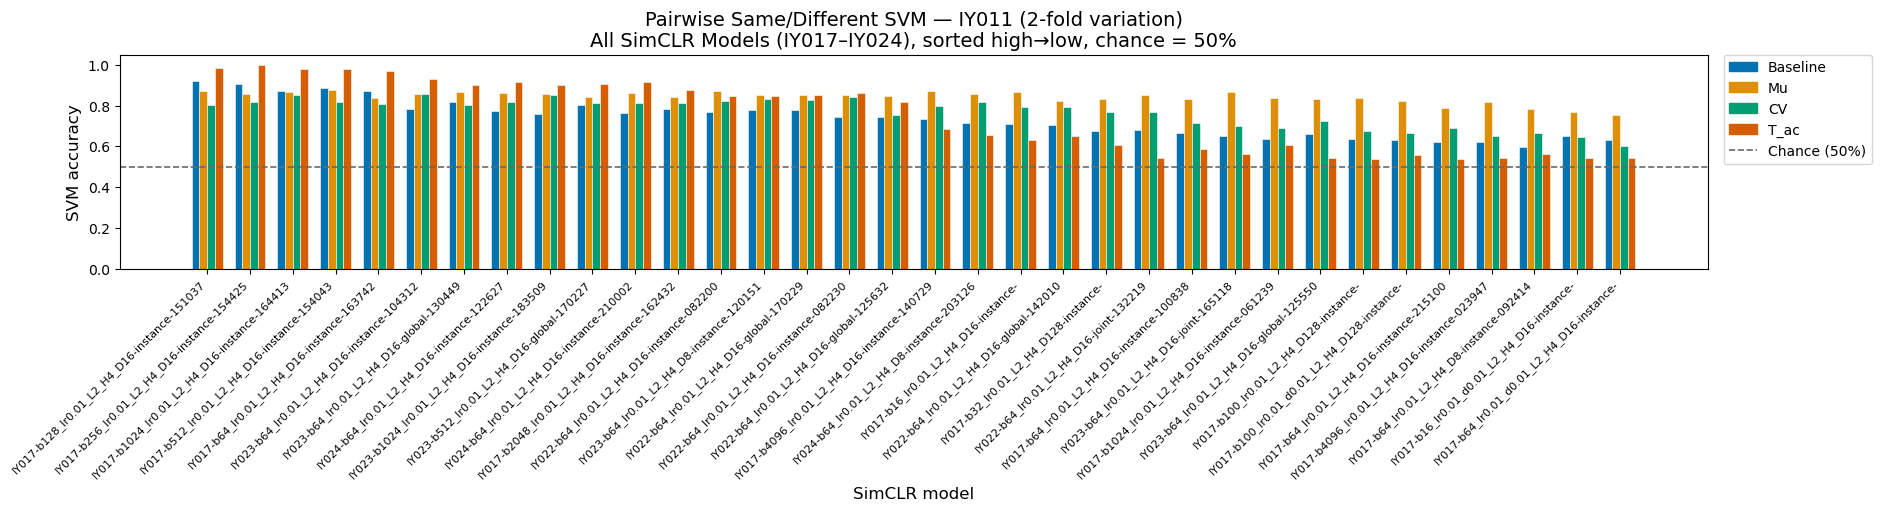

Saved IY029_simclr_svm_pairwise_2fold.png


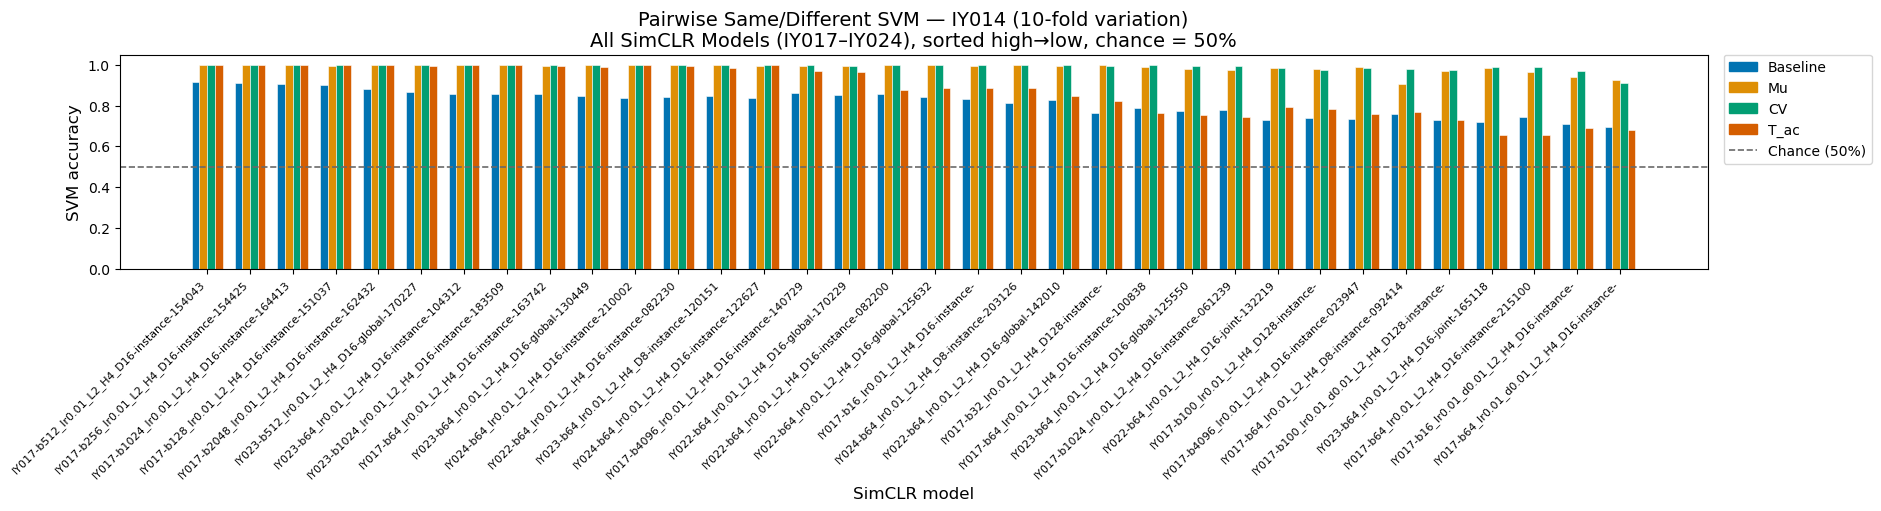

Saved IY029_simclr_svm_pairwise_10fold.png


In [6]:
import matplotlib.patches as mpatches

palette      = sns.color_palette('colorblind')
ds_colors    = {name: palette[i] for i, name in enumerate(ds_names)}
model_labels = [label for _, label in MODEL_REGISTRY]


def plot_fold(fold_key: str, fold_title: str, fname: str):
    """Bar chart of all models × 4 datasets, sorted high→low by mean accuracy."""
    n_ds    = len(ds_names)
    width   = 0.18
    offsets = np.linspace(-(n_ds - 1) / 2 * width, (n_ds - 1) / 2 * width, n_ds)

    # Sort models by mean accuracy across datasets for this fold
    sorted_labels = sorted(
        model_labels,
        key=lambda lbl: np.mean([results[lbl][ds][fold_key] for ds in ds_names]),
        reverse=True,
    )
    x = np.arange(len(sorted_labels))

    fig, ax = plt.subplots(figsize=(max(16, len(sorted_labels) * 0.55), 5),
                           constrained_layout=True)

    for j, ds_name in enumerate(ds_names):
        accs = [results[lbl][ds_name][fold_key] for lbl in sorted_labels]
        ax.bar(x + offsets[j], accs, width=width,
               color=ds_colors[ds_name], label=ds_name,
               edgecolor='white', linewidth=0.4)

    ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1.2,
               label='Chance (50%)')
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('SimCLR model', fontsize=12)
    ax.set_ylabel('SVM accuracy', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Pairwise Same/Different SVM — {fold_title}\n'
                 f'All SimCLR Models (IY017–IY024), sorted high→low, chance = 50%',
                 fontsize=14)

    legend_handles = [
        mpatches.Patch(color=ds_colors[n], label=n) for n in ds_names
    ] + [plt.Line2D([0], [0], color='dimgrey', linestyle='--',
                    linewidth=1.2, label='Chance (50%)')]
    ax.legend(handles=legend_handles, fontsize=10,
              bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


# ── Plot 1: 2-fold (IY011) ────────────────────────────────────────────────────
plot_fold('iy011', 'IY011 (2-fold variation)', 'IY029_simclr_svm_pairwise_2fold.png')

# ── Plot 2: 10-fold (IY014) ───────────────────────────────────────────────────
plot_fold('iy014', 'IY014 (10-fold variation)', 'IY029_simclr_svm_pairwise_10fold.png')


Best model: IY017-b256_lr0.01_L2_H4_D16-instance-154425  (mean acc = 0.936)


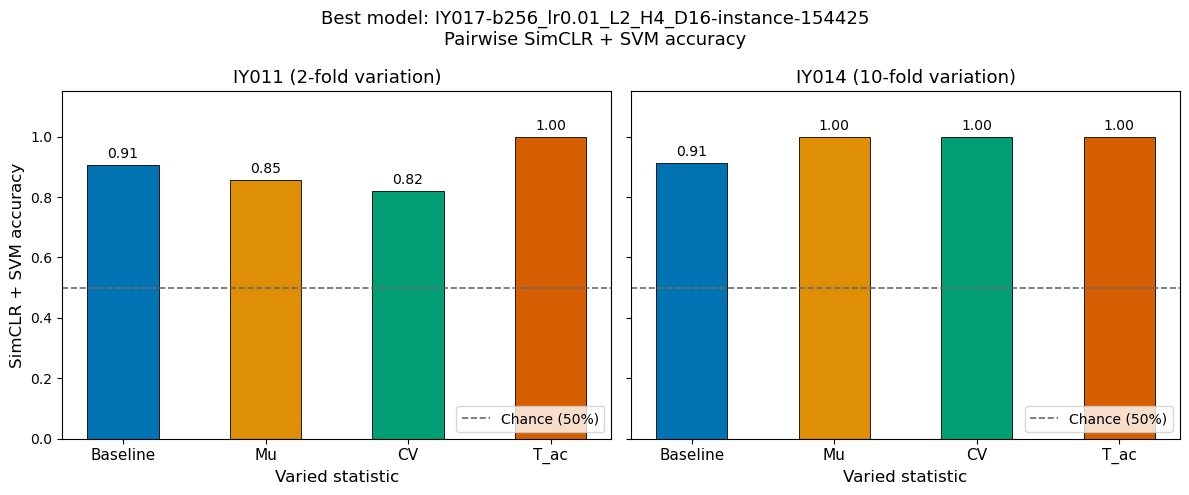

Saved IY029_simclr_svm_pairwise_best_model.png


In [7]:
# ── Plot 3: Best model — side-by-side subplots for 2-fold and 10-fold ─────────
mean_accs = {
    lbl: np.mean([
        results[lbl][ds][fold]
        for ds in ds_names
        for fold in ('iy011', 'iy014')
    ])
    for lbl in model_labels
}
best_label = max(mean_accs, key=mean_accs.get)
print(f'Best model: {best_label}  (mean acc = {mean_accs[best_label]:.3f})')

accs_2fold  = [results[best_label][ds]['iy011'] for ds in ds_names]
accs_10fold = [results[best_label][ds]['iy014'] for ds in ds_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

x      = np.arange(len(ds_names))
width  = 0.5
colors = [ds_colors[ds] for ds in ds_names]   # one colour per dataset, matching IY025

for ax, accs, fold_title in [
    (axes[0], accs_2fold,  'IY011 (2-fold variation)'),
    (axes[1], accs_10fold, 'IY014 (10-fold variation)'),
]:
    bars = ax.bar(x, accs, width, color=colors, edgecolor='black', linewidth=0.6)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1.2, label='Chance (50%)')
    ax.set_xticks(x)
    ax.set_xticklabels(ds_names, fontsize=11)
    ax.set_xlabel('Varied statistic', fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_title(fold_title, fontsize=13)
    ax.legend(fontsize=10, loc='lower right')

axes[0].set_ylabel('SimCLR + SVM accuracy', fontsize=12)
fig.suptitle(f'Best model: {best_label}\nPairwise SimCLR + SVM accuracy', fontsize=13)

plt.tight_layout()
plt.savefig('IY029_simclr_svm_pairwise_best_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved IY029_simclr_svm_pairwise_best_model.png')


In [8]:
import pandas as pd

# Summary table: rows = models, cols = (dataset, fold)
rows = []
for lbl in model_labels:
    row = {'model': lbl}
    for ds in ds_names:
        row[f'{ds} 2-fold']  = results[lbl][ds]['iy011']
        row[f'{ds} 10-fold'] = results[lbl][ds]['iy014']
    row['mean'] = mean_accs[lbl]
    rows.append(row)

df = pd.DataFrame(rows).set_index('model').sort_values('mean', ascending=False)
pd.set_option('display.float_format', '{:.3f}'.format)
print(df.to_string())

                                              Baseline 2-fold  Baseline 10-fold  Mu 2-fold  Mu 10-fold  CV 2-fold  CV 10-fold  T_ac 2-fold  T_ac 10-fold  mean
model                                                                                                                                                         
IY017-b256_lr0.01_L2_H4_D16-instance-154425             0.905             0.913      0.855       1.000      0.820       1.000        0.998         1.000 0.936
IY017-b128_lr0.01_L2_H4_D16-instance-151037             0.918             0.903      0.872       0.997      0.805       1.000        0.983         1.000 0.935
IY017-b512_lr0.01_L2_H4_D16-instance-154043             0.885             0.917      0.878       0.998      0.817       1.000        0.982         1.000 0.935
IY017-b1024_lr0.01_L2_H4_D16-instance-164413            0.870             0.905      0.865       1.000      0.853       1.000        0.980         1.000 0.934
IY017-b64_lr0.01_L2_H4_D16-instance-163742    

## Combined Feature: [z1_raw, z2_raw, z1_encoded, z2_encoded]

Augments the SimCLR embeddings with the raw cropped trajectories, so the SVM can exploit both the learned representation and the raw temporal signal simultaneously.

Feature vector per pair: `[x1_raw (SAMPLE_LEN), x2_raw (SAMPLE_LEN), z1 (d_model), z2 (d_model)]`


In [9]:
def encode_pairs_combined(model: SSL_Transformer, X_np: np.ndarray,
                          device, batch_size: int = 256) -> np.ndarray:
    """
    Returns [x1_raw | x2_raw | z1_encoded | z2_encoded] per pair.
    Shape: (N, 2*SAMPLE_LEN + 2*d_model).
    Gives the SVM both the raw temporal signal and the learned representation.
    """
    T    = X_np.shape[1]
    half = T // 2
    x1 = X_np[:, :SAMPLE_LEN,  :]           # (N, SAMPLE_LEN, 1)
    x2 = X_np[:, half:half + SAMPLE_LEN, :] # (N, SAMPLE_LEN, 1)

    z1_parts, z2_parts = [], []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            b1 = torch.tensor(x1[i:i+batch_size], dtype=torch.float32).to(device)
            b2 = torch.tensor(x2[i:i+batch_size], dtype=torch.float32).to(device)
            z1_parts.append(model.backbone.encode(b1).cpu().numpy())
            z2_parts.append(model.backbone.encode(b2).cpu().numpy())

    z1 = np.concatenate(z1_parts, axis=0)   # (N, d_model)
    z2 = np.concatenate(z2_parts, axis=0)   # (N, d_model)

    x1_flat = x1.reshape(len(X_np), -1)     # (N, SAMPLE_LEN)
    x2_flat = x2.reshape(len(X_np), -1)     # (N, SAMPLE_LEN)

    return np.concatenate([x1_flat, x2_flat, z1, z2], axis=1)


def run_svm_combined(model, X_train, X_test, y_train, y_test, device):
    """Encode with combined features, scale, fit RBF SVM, return test accuracy."""
    feats_tr = encode_pairs_combined(model, X_train, device)
    feats_te = encode_pairs_combined(model, X_test,  device)

    scaler   = StandardScaler()
    feats_tr = scaler.fit_transform(feats_tr)
    feats_te = scaler.transform(feats_te)

    clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    clf.fit(feats_tr, y_train)
    return clf.score(feats_te, y_test)


# ── Main loop with combined features ─────────────────────────────────────────
results_combined = {}

for ckpt_path, label in tqdm(MODEL_REGISTRY, desc='Models (combined)'):
    results_combined[label] = {}
    model = load_model(ckpt_path, DEVICE)

    for ds_name in ds_names:
        results_combined[label][ds_name] = {}
        for fold in ('iy011', 'iy014'):
            X_tr, X_te, y_tr, y_te = prepared_data[ds_name][fold]
            acc = run_svm_combined(model, X_tr, X_te, y_tr, y_te, DEVICE)
            results_combined[label][ds_name][fold] = acc

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('Done.')


Models (combined):   0%|          | 0/34 [00:00<?, ?it/s]

Models (combined):   3%|▎         | 1/34 [00:39<21:39, 39.38s/it]

Models (combined):   6%|▌         | 2/34 [01:18<21:03, 39.48s/it]

Models (combined):   9%|▉         | 3/34 [01:51<18:45, 36.32s/it]

Models (combined):  12%|█▏        | 4/34 [02:25<17:43, 35.47s/it]

...

Models (combined):  94%|█████████▍| 32/34 [18:12<01:07, 33.56s/it]

Models (combined):  97%|█████████▋| 33/34 [18:45<00:33, 33.51s/it]

Models (combined): 100%|██████████| 34/34 [19:19<00:00, 33.55s/it]

Models (combined): 100%|██████████| 34/34 [19:19<00:00, 34.10s/it]

Done.


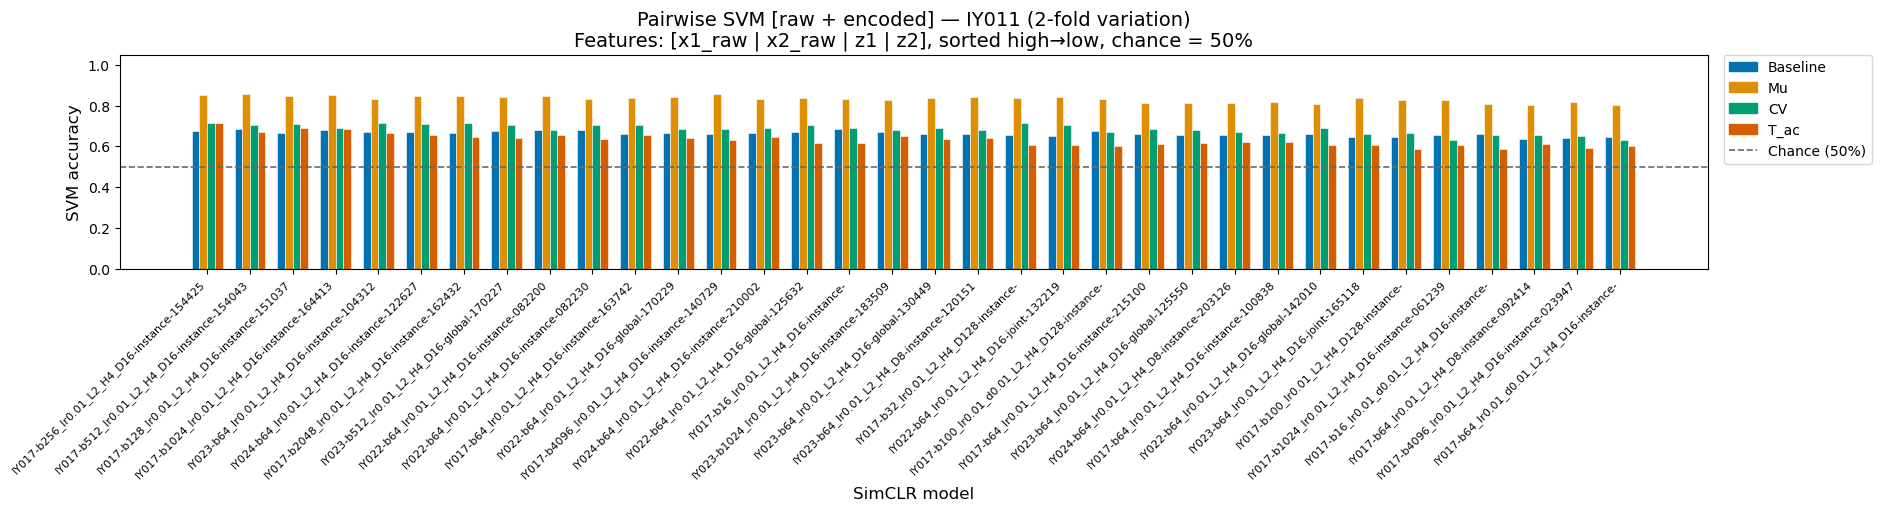

Saved IY029_simclr_svm_pairwise_combined_2fold.png


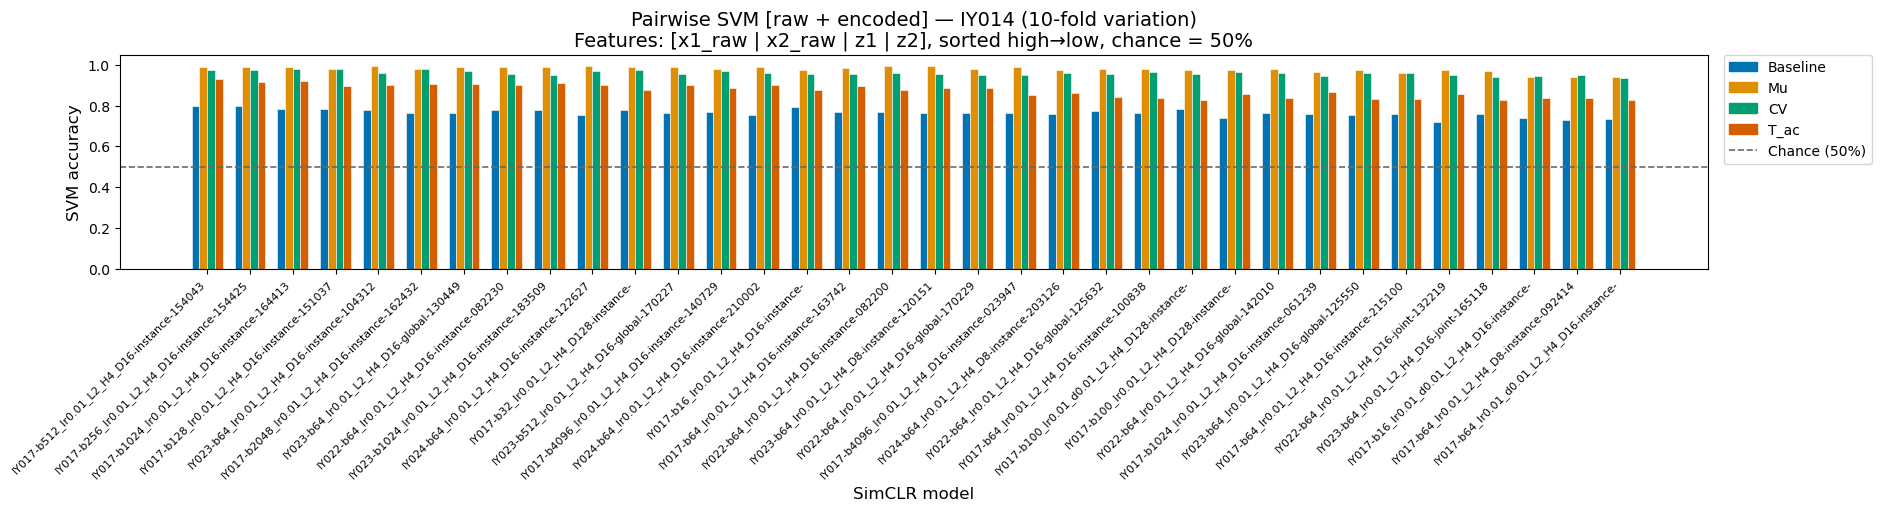

Saved IY029_simclr_svm_pairwise_combined_10fold.png


In [10]:
def plot_fold_combined(fold_key: str, fold_title: str, fname: str):
    """Bar chart sorted high→low for the combined-feature results."""
    n_ds    = len(ds_names)
    width   = 0.18
    offsets = np.linspace(-(n_ds - 1) / 2 * width, (n_ds - 1) / 2 * width, n_ds)

    sorted_labels = sorted(
        model_labels,
        key=lambda lbl: np.mean([results_combined[lbl][ds][fold_key] for ds in ds_names]),
        reverse=True,
    )
    x = np.arange(len(sorted_labels))

    fig, ax = plt.subplots(figsize=(max(16, len(sorted_labels) * 0.55), 5),
                           constrained_layout=True)

    for j, ds_name in enumerate(ds_names):
        accs = [results_combined[lbl][ds_name][fold_key] for lbl in sorted_labels]
        ax.bar(x + offsets[j], accs, width=width,
               color=ds_colors[ds_name], edgecolor='white', linewidth=0.4)

    ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1.2, label='Chance (50%)')
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('SimCLR model', fontsize=12)
    ax.set_ylabel('SVM accuracy', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Pairwise SVM [raw + encoded] — {fold_title}\n'
                 f'Features: [x1_raw | x2_raw | z1 | z2], sorted high→low, chance = 50%',
                 fontsize=14)

    legend_handles = [
        mpatches.Patch(color=ds_colors[n], label=n) for n in ds_names
    ] + [plt.Line2D([0], [0], color='dimgrey', linestyle='--',
                    linewidth=1.2, label='Chance (50%)')]
    ax.legend(handles=legend_handles, fontsize=10,
              bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


plot_fold_combined('iy011', 'IY011 (2-fold variation)',  'IY029_simclr_svm_pairwise_combined_2fold.png')
plot_fold_combined('iy014', 'IY014 (10-fold variation)', 'IY029_simclr_svm_pairwise_combined_10fold.png')


Best model (combined): IY017-b256_lr0.01_L2_H4_D16-instance-154425  (mean = 0.829)


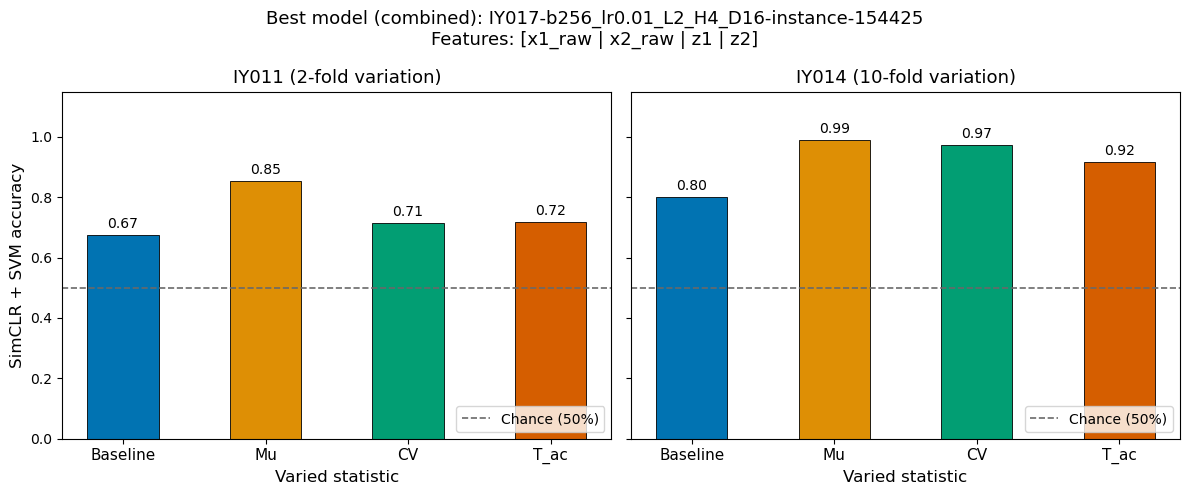

Saved IY029_simclr_svm_pairwise_combined_best_model.png


In [11]:
# Best model for combined features — side-by-side subplots
mean_accs_combined = {
    lbl: np.mean([results_combined[lbl][ds][fold]
                  for ds in ds_names for fold in ('iy011', 'iy014')])
    for lbl in model_labels
}
best_combined = max(mean_accs_combined, key=mean_accs_combined.get)
print(f'Best model (combined): {best_combined}  (mean = {mean_accs_combined[best_combined]:.3f})')

accs_2fold  = [results_combined[best_combined][ds]['iy011'] for ds in ds_names]
accs_10fold = [results_combined[best_combined][ds]['iy014'] for ds in ds_names]
colors = [ds_colors[ds] for ds in ds_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
x, width = np.arange(len(ds_names)), 0.5

for ax, accs, fold_title in [
    (axes[0], accs_2fold,  'IY011 (2-fold variation)'),
    (axes[1], accs_10fold, 'IY014 (10-fold variation)'),
]:
    bars = ax.bar(x, accs, width, color=colors, edgecolor='black', linewidth=0.6)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1.2, label='Chance (50%)')
    ax.set_xticks(x)
    ax.set_xticklabels(ds_names, fontsize=11)
    ax.set_xlabel('Varied statistic', fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_title(fold_title, fontsize=13)
    ax.legend(fontsize=10, loc='lower right')

axes[0].set_ylabel('SimCLR + SVM accuracy', fontsize=12)
fig.suptitle(f'Best model (combined): {best_combined}\n'
             f'Features: [x1_raw | x2_raw | z1 | z2]', fontsize=13)
plt.tight_layout()
plt.savefig('IY029_simclr_svm_pairwise_combined_best_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved IY029_simclr_svm_pairwise_combined_best_model.png')
